# Particle in a Box and Molecular Conjugation

In this lab, we will build, test, and compare mathematical models that describe electrons confined within molecules. Starting from physical principles, we will construct a particle-in-a-box model, solve it numerically, and compare its predictions to full quantum-chemical calculations on real molecules. Along the way, you will practice curve fitting, numerical optimization, and computational chemistry — skills that are central to modern physical chemistry research.

---

**Chemistry Learning Objectives:**
- C4.1: Solve the Schrödinger equation for the particle in a box using numerical methods.
- C4.2: Connect features of PIB wavefunctions to their energies.
- C4.3: Use the Self-Consistent Field (Hartree-Fock) method to model molecules.
- C4.4: Evaluate the utility PIB and SCF models for predicting properties of conjugated polyenes.

**Programming Learning Objectives:**
- P4.1: Perform numerical optimization routines with `scipy`.
- P4.2: Fit nonlinear curves to data using numerical optimization.
- P4.3: Perform quantum chemical calculations with the `psi4` software package.

---

**Table of Contents**
- [Warmup — Curve Fitting](#warmup)
- [Part 1 — Solving the Schrödinger Equation](#part1)
- [Part 2 — Energy Levels of the Particle in a Box](#part2)
- [Part 3 — Computational Chemistry](#part3)
- [Part 4 — Comparing Models](#part4)
- [Reflection](#reflection)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

<a id="warmup"></a>

## Warmup — Curve Fitting and Physical Models

The statistician George Box famously observed:

> *"All models are wrong, but some are useful."*

Throughout science, we use **models** — simplified mathematical descriptions — to make sense of complex systems. A model does not need to be perfect to be valuable; it needs to capture the features we care about. In this lab, we will build several models of increasing sophistication and evaluate how well each one works.

A foundational skill for working with models is **curve fitting**: given experimental (or computational) data, finding a mathematical function that describes it. Let's practice this now.

### Coding Activity (Warmup)
`15 points`

- P4.2: Fit nonlinear curves to data.

You have gotten some practice performing linear regression on data. You aren't limited to this - you can actually fit arbitrary functional forms. We'll use `scipy.optimize.curve_fit` for this.


### W.A

Let's take a look at this mysterious data. By now, you should be able to load data using `pandas` and plot it using `matplotlib`.

**Your task:**
1. Load the data from `data/mystery_curve.csv` 
2. Make a scatter plot with axis labels and a title.


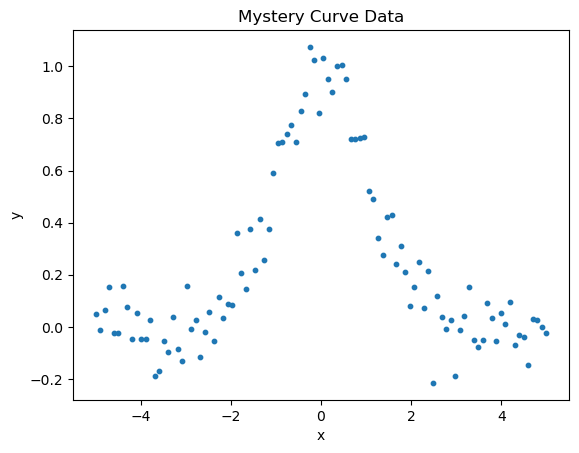

In [2]:
# Subgoal: Load and inspect the data
mystery_curve = pd.read_csv('data/mystery_curve.csv')
plt.scatter(mystery_curve['x'], mystery_curve['y'], s=10)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Mystery Curve Data')
plt.show()

### W.B - Learning from a worked example

Now we will practice fitting functions of our creation to this data! We'll use [`scipy.optimize.curve_fit`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html) — read the linked documentation if you want more detail on how it works.

**Your task:**
1. Read the code in the two cells below carefully.
2. Add a comment to each line explaining what it does and why.
3. Run both cells and observe the output.

In [ ]:
from scipy.optimize import curve_fit #        YOUR COMMENT HERE

def abs_x(x, m, b):                           # YOUR COMMENT HERE
    return m * np.abs(x) + b                  # YOUR COMMENT HERE

params, covariance = curve_fit(
                    abs_x,                    # YOUR COMMENT HERE
                    mystery_curve['x'],       # YOUR COMMENT HERE
                    mystery_curve['y'],       # YOUR COMMENT HERE
                    p0=[1, 0])                # YOUR COMMENT HERE
print("Params:", params)

In [ ]:
plt.scatter(mystery_curve['x'], mystery_curve['y'], label='Data')  # YOUR COMMENT HERE

x_fit = np.linspace(-5, 5, 100)               # YOUR COMMENT HERE
m = params[0]                                  # YOUR COMMENT HERE
b = params[1]                                  # YOUR COMMENT HERE
y_fit = abs_x(x_fit, m, b)                    # YOUR COMMENT HERE
plt.plot(x_fit, y_fit, label='Fitted', color='red')  # YOUR COMMENT HERE

plt.xlabel('x')                                # YOUR COMMENT HERE
plt.ylabel('y')                                # YOUR COMMENT HERE
plt.title('Fitting Abs x Function')            # YOUR COMMENT HERE
plt.legend()                                   # YOUR COMMENT HERE
plt.show()

### W.C - Fitting your own function

Now it's your turn! Define a different function and fit it to the same data.

**Your task:**
1. Define a new candidate function (e.g., Gaussian, exponential decay, quadratic — anything you think might match the shape of the data).
2. Use `curve_fit` to find the best parameters.
3. Plot the data and your fitted curve together.
4. Does your function fit the data better or worse than the absolute-value function above?

In [ ]:
# Subgoal: Define your candidate function
# # YOUR CODE HERE

# Subgoal: Fit your function to the data
# params_mine, covariance_mine = curve_fit(...)

# Subgoal: Plot the data and your fitted curve
# plt.scatter(...)
# plt.plot(...)
# plt.xlabel(...)
# plt.ylabel(...)
# plt.title(...)
# plt.legend()
# plt.show()

### Question (Warmup)
`5 points`

a) Which of your candidate functions best fit the data? How did you decide?

b) Propose an example of a situation where you could use this technique in a real scientific application.

c) In the example you gave, how would the curve be useful to us? How about the parameters?

---

*Your answer here (`double click me!`):*

<br></br>